# Fase 3 : Módulo No Supervisado (Clustering)

K-Means sobre variables sociodemográficas y geográficas. Validación con Método del Codo y Coeficiente de Silueta.

### Importación de Librerías y Extracción desde SQL Server

In [5]:
#import sys
#!{sys.executable} -m pip install matplotlib seaborn

In [6]:
#import sys
#!{sys.executable} -m pip install scikit-learn

In [14]:
# ============================================================================
# BLOQUE 1: EXTRACCIÓN DE DATOS PARA MODELADO DE CLUSTERING
# ============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Conexión a la base de datos blindada
engine = create_engine('mssql+pyodbc://DESKTOP-Q2AD3LV/DB_PersonasDesaparecidas?driver=ODBC+Driver+17+for+SQL+Server&trusted_connection=yes')

# Query de extracción consolidando hechos y dimensiones
query = """
SELECT 
    g.provincia,
    g.canton,
    p.edad,
    f.dias_solucion,
    f.estado_desaparecido
FROM Fact_Casos f
INNER JOIN Dim_Persona p ON f.id_persona = p.id_persona
INNER JOIN Dim_Geografia g ON f.id_geografia = g.id_geografia;
"""

df_raw = pd.read_sql(query, con=engine)
print(f">>> Datos extraídos con éxito. Total registros para análisis: {df_raw.shape[0]}")

>>> Datos extraídos con éxito. Total registros para análisis: 75680


### Ingeniería de Características a Nivel de Cantón (Agregación)

In [19]:
# ============================================================================
# BLOQUE 2 REFORMULADO: AGREGACIÓN POR CANTÓN CON ESTADOS REALES
# ============================================================================
print(">>> Generando variables agregadas por Cantón para el modelo...")

# Calcular métricas clave por cantón usando los estados reales detectados
df_canton = df_raw.groupby(['provincia', 'canton']).agg(
    total_casos=('estado_desaparecido', 'count'),
    edad_promedio=('edad', 'mean'),
    # Porcentaje de casos que siguen "EN INVESTIGACIÓN"
    porcentaje_sin_resolver=('estado_desaparecido', lambda x: (x == 'EN INVESTIGACIÓN').sum() / len(x) * 100)
).reset_index()

# Filtrar cantones con muy pocos registros para evitar ruido estadístico (Outliers)
df_canton = df_canton[df_canton['total_casos'] >= 5].reset_index(drop=True)

print(f" Perfiles geográficos construidos. Cantones a evaluar: {df_canton.shape[0]}")
df_canton.head()

>>> Generando variables agregadas por Cantón para el modelo...
 Perfiles geográficos construidos. Cantones a evaluar: 216


,provincia,canton,total_casos,edad_promedio,porcentaje_sin_resolver
0,AZUAY,CAMILO PONCE ENRÍQUEZ,90,25.844444,12.222222
1,AZUAY,CHORDELEG,27,29.370370,0.000000
2,AZUAY,CUENCA,2979,23.315878,2.383350
3,AZUAY,GIRÓN,33,27.696970,6.060606
4,AZUAY,GUACHAPALA,8,29.750000,0.000000


### Escalado de Datos y Método del Codo (Elbow Method)

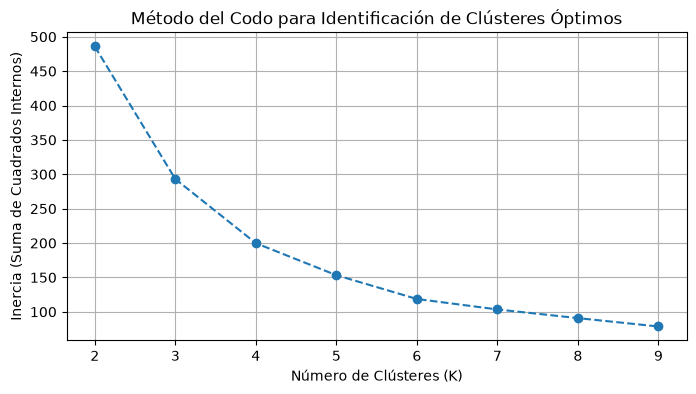

In [20]:
# ============================================================================
# BLOQUE 3 REFORMULADO: ESCALADO SÓLO CON VARIABLES CON VARIANZA
# ============================================================================
# Seleccionar solo las variables que tienen datos reales y variabilidad
features = ['total_casos', 'edad_promedio', 'porcentaje_sin_resolver']
X = df_canton[features]

# Escalar los datos (Media = 0, Varianza = 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Calcular la inercia para diferentes valores de K
inercias = []
valores_k = range(2, 10)

for k in valores_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inercias.append(kmeans.inertia_)

# Graficar el método del Codo
plt.figure(figsize=(8, 4))
plt.plot(valores_k, inercias, marker='o', color='#1f77b4', linestyle='--')
plt.title('Método del Codo para Identificación de Clústeres Óptimos')
plt.xlabel('Número de Clústeres (K)')
plt.ylabel('Inercia (Suma de Cuadrados Internos)')
plt.grid(True)
plt.show()

### Entrenamiento de K-Means y Asignación de Clústeres

In [21]:
# ============================================================================
# BLOQUE 4 CORREGIDO: ENTRENAMIENTO DE K-MEANS Y CARACTERIZACIÓN
# ============================================================================
# Definimos el K óptimo basándonos en la gráfica del codo ajustada
k_optimo = 4 

kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)

# Ajustamos y asignamos las etiquetas directamente al DataFrame de cantones
df_canton['cluster'] = kmeans_final.fit_predict(X_scaled)

# Calcular el score de Silueta para evaluar la calidad del agrupamiento
score_silueta = silhouette_score(X_scaled, df_canton['cluster'])
print(f">>> Modelo K-Means entrenado con éxito con K={k_optimo}.")
print(f" ➔ Coeficiente de Silueta General: {score_silueta:.4f}\n")

# CORRECCIÓN: Lista de características ajustada a las variables con varianza real
features = ['total_casos', 'edad_promedio', 'porcentaje_sin_resolver']

# Mostrar el perfil promedio de cada clúster encontrado en Ecuador
perfiles = df_canton.groupby('cluster')[features].mean()
print("======= PERFIL ESTADÍSTICO DE LOS CLÚSTERES IDENTIFICADOS =======")
print(perfiles)

>>> Modelo K-Means entrenado con éxito con K=4.
 ➔ Coeficiente de Silueta General: 0.4017

======= PERFIL ESTADÍSTICO DE LOS CLÚSTERES IDENTIFICADOS =======
          total_casos  edad_promedio  porcentaje_sin_resolver
cluster                                                      
0          284.319444      20.547010                 4.611822
1        14539.500000      24.636231                 2.658601
2           38.000000      30.019425                48.623463
3           84.640625      26.711342                 7.862361


In [ ]:
# ============================================================================
# BLOQUE 5: PERSISTENCIA EN LA RAÍZ Y LOGS EN MONGODB 
# ============================================================================
import joblib
import pymongo
import os
from datetime import datetime

# 1. Retroceder dos niveles de forma segura: de 02_clustering -> notebooks -> raíz del proyecto
base_dir = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
models_dir = os.path.join(base_dir, "models")

# Plan de contingencia: Asegurar que se use o cree la carpeta 'models' principal
os.makedirs(models_dir, exist_ok=True)

path_modelo = os.path.join(models_dir, "kmeans_model.pkl")
path_scaler = os.path.join(models_dir, "clustering_scaler.pkl")

# Exportar los archivos binarios de forma segura a la raíz del proyecto
joblib.dump(kmeans_final, path_modelo)
joblib.dump(scaler, path_scaler)
print(f">>> ¡Modelos de Clustering guardados con éxito en la raíz: {models_dir}!")

# 2. Registrar los resultados analíticos en tu repositorio NoSQL
client = pymongo.MongoClient("mongodb://localhost:27017/")
db_mongo = client["DB_PersonasDesaparecidas_NoSQL"]
col_metricas = db_mongo["Metricas_Modelos"]

# CORRECCIÓN: Convertir el índice del DataFrame a String para evitar restricciones de MongoDB
perfiles_en_texto = perfiles.copy()
perfiles_en_texto.index = perfiles_en_texto.index.astype(str)

documento_clustering = {
    "experimento": "Clustering_KMeans_Cantonal_V1",
    "fecha_ejecucion": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "k_optimo": int(k_optimo),
    "silhouette_score": float(score_silueta),
    "tipo_modelo": "No_Supervisado",
    "perfiles_descubiertos": perfiles_en_texto.to_dict(orient='index')
}

col_metricas.update_one({"experimento": "Clustering_KMeans_Cantonal_V1"}, {"$set": documento_clustering}, upsert=True)
print(">>> ¡Métricas de clustering e historial indexados correctamente en MongoDB!")

>>> ¡Modelos de Clustering guardados con éxito en la raíz: c:\Users\HP\OneDrive\proyecto-personas-desaparecidas\models!
>>> ¡Métricas de clustering e historial indexados correctamente en MongoDB!
